In [1]:
%load_ext rpy2.ipython

## Deciles

In [2]:
import pandas as pd

def classify_loops(loops_path, tads_path, output_path):
    """
    Classify loops based on their position relative to TADs and save the results.
    
    Args:
        loops_path (str): Path to loops BED file
        tads_path (str): Path to TAD boundaries BED file
        output_path (str): Output file path for classified loops
    """
    # Load data
    loops_df = pd.read_csv(
        loops_path, 
        sep="\t", 
        header=None, 
        names=["chr1", "start1", "end1", "chr2", "start2", "end2", "element"]
    )
    tads_df = pd.read_csv(
        tads_path, 
        sep="\t", 
        header=None, 
        names=["chr", "start", "end"]
    )
    
   
    loops_df[['start1', 'end1', 'start2', 'end2']] = loops_df[['start1', 'end1', 'start2', 'end2']].astype(int)
    tads_df[['start', 'end']] = tads_df[['start', 'end']].astype(int)
    
    # Preprocess TADs: create nested dictionary {chrom: {TAD_index: [start, end]}}
    chrom_tads = {}
    for _, row in tads_df.iterrows():
        chrom = row['chr']
        if chrom not in chrom_tads:
            chrom_tads[chrom] = {}
        chrom_tads[chrom][len(chrom_tads[chrom])] = [row['start'], row['end']]
    
    # Find TAD containing a genomic position
    def find_tad(chrom, pos):
        pos = int(pos) 
        if chrom not in chrom_tads:
            return None
        for tad_idx, (start, end) in chrom_tads[chrom].items():
            if start <= pos <= end:
                return tad_idx
        return None
    
    # Classify each loop
    classifications = []
    for _, row in loops_df.iterrows():
        chr1, chr2 = row['chr1'], row['chr2']
        pos1, pos2 = row['start1'], row['start2']
        
        # Inter-chromosomal loop
        if chr1 != chr2:
            classifications.append("Inter-chromosomal")
            continue
            
        # Intra-chromosomal loop
        tad1 = find_tad(chr1, pos1)
        tad2 = find_tad(chr2, pos2)
        
        if tad1 is None or tad2 is None:
            classifications.append("Unclassified")
        elif tad1 == tad2:
            classifications.append("Within One TAD")
        elif abs(tad1 - tad2) == 1:
            classifications.append("Adjacent TADs")
        else:
            classifications.append("Distant TADs")
    
    loops_df['classification'] = classifications
    loops_df.to_csv(output_path, sep='\t', index=False, header=False)


In [3]:
configs = [
    {
        'loop_type': 'dec1',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec1_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec1_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec1',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec1_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec1_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec2',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec2_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec2_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec2',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec2_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec2_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec3',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec3_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec3_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec3',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec3_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec3_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec4',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec4_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec4_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec4',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec4_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec4_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec5',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec5_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec5_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec5',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec5_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec5_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec6',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec6_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec6_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec6',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec6_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec6_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec7',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec7_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec7_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec7',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec7_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec7_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec8',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec8_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec8_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec8',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec8_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec8_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec9',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec9_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec9_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec9',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec9_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec9_KO_adl_classified.bed"
    },
    {
        'loop_type': 'dec10',
        'condition': 'old_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec10_old_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec10_old_adl_classified.bed"
    },
    {
        'loop_type': 'dec10',
        'condition': 'KO_adl',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec10_KO_adl_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec10_KO_adl_classified.bed"
    }
]

for conf in configs:
    print(f"Processing {conf['loop_type']} loops for {conf['condition']}...")
    classify_loops(conf['loops_path'], conf['tads_path'], conf['output_path'])
    print(f"Saved results to {conf['output_path']}\n")

Processing dec1 loops for old_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec1_old_adl_classified.bed

Processing dec1 loops for KO_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec1_KO_adl_classified.bed

Processing dec2 loops for old_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec2_old_adl_classified.bed

Processing dec2 loops for KO_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec2_KO_adl_classified.bed

Processing dec3 loops for old_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec3_old_adl_classified.bed

Processing dec3 loops for KO_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec3_KO_adl_classified.bed

Processing dec4 loops for old_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/dec4_old_adl_classified.bed

Processing dec4 loops for KO_adl...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/d

## Old/Adult

In [4]:
%%R

library(reticulate)
library(tidyverse)
library(patchwork)

dec1 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec1_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec2 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec2_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec3 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec3_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2","element",  "classification"))

dec4 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec4_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec5 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec5_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec6 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec6_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec7 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec7_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec8 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec8_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec9 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec9_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec10 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec10_old_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

deciles <- list(dec1, dec2, dec3, dec4, dec5, dec6, dec7, dec8, dec9, dec10)

for(i in seq_along(deciles)){
  deciles[[i]]$type <- paste0("Decile", i)
  deciles[[i]]$Type <- "Old/Adult"
}

df_all <- bind_rows(deciles)

df_all$type <- factor(df_all$type, levels = unique(df_all$type))
#df_all$Type <- factor(df_all$Type, levels = c("Old/Adult", "S6-KO/Adult"))
df_all$classification <- factor(df_all$classification,
                                levels = c("Within One TAD", "Adjacent TADs", "Distant TADs"))


pal <- c("lemonchiffon2", "lavender", "tan2")

common_theme <- theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, color = "black"),
    axis.text.y = element_text(size = 15, color = "black"),
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    legend.position = "bottom",
    legend.title = element_text(size = 11),
    legend.text = element_text(size = 10),
    aspect.ratio = 2/1
  )

# --- plot for Old/Adult ---
p_old <- ggplot(df_all, aes(x = type, fill = classification)) +
  geom_bar(position = "fill", color = "black", width = 0.7) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_manual(values = pal, name = "TAD relationship") +
  labs(title = "Old vs Adult", x = "", y = "") +
  common_theme




    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


## S6-KO/Adult

In [5]:
%%R

dec1 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec1_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec2 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec2_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec3 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec3_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2","element",  "classification"))

dec4 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec4_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec5 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec5_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec6 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec6_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec7 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec7_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec8 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec8_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec9 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec9_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))

dec10 <- read.table("/tank/projects/kashuk_sirt6_hic/loops_10k/diff/deciles/dec10_KO_adl_classified.bed",
                     sep = "\t", header = FALSE,
                     col.names = c("chr1","start1","end1","chr2","start2","end2", "element", "classification"))


deciles <- list(dec1, dec2, dec3, dec4, dec5, dec6, dec7, dec8, dec9, dec10)

for(i in seq_along(deciles)){
  deciles[[i]]$type <- paste0("Decile", i)
  deciles[[i]]$Type <- "S6-KO/Adult"
}

df_all <- bind_rows(deciles)

df_all$type <- factor(df_all$type, levels = unique(df_all$type))
#df_all$Type <- factor(df_all$Type, levels = c("Old/Adult", "S6-KO/Adult"))
df_all$classification <- factor(df_all$classification,
                                levels = c("Within One TAD", "Adjacent TADs", "Distant TADs"))


pal <- c("lemonchiffon2", "lavender", "tan2")

common_theme <- theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, color = "black"),
    axis.text.y = element_text(size = 15, color = "black"),
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    legend.position = "bottom",
    legend.title = element_text(size = 11),
    legend.text = element_text(size = 10),
    aspect.ratio = 2/1
  )

# --- plot for S6-KO/Adult
p_ko <- ggplot(df_all, aes(x = type, fill = classification)) +
  geom_bar(position = "fill", color = "black", width = 0.7) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_manual(values = pal, name = "TAD relationship") +
  labs(title = "S6-KO vs Adult", x = "", y = "") +
  common_theme

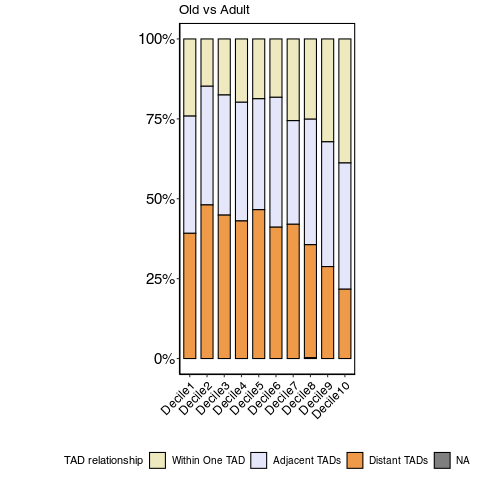

In [6]:
%%R 

p_old

#ggsave("/tank/projects/kashuk_sirt6_hic/loops_10k/TADs_loops_old_adl_deciles.png", plot = p_old, dpi = 1200)

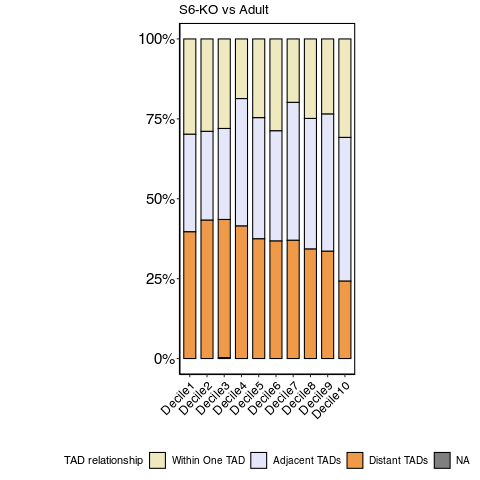

In [7]:
%%R 

p_ko

#ggsave("/tank/projects/kashuk_sirt6_hic/loops_10k/TADs_loops_KO_adl_deciles.png", plot = p_ko, dpi = 1200)